In [91]:
import pandas as pd
import requests 
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import metrics
from sklearn import ensemble
import matplotlib.pyplot as plt

In [92]:
###############################
#
# Pulling Data from SportsIO API, for 2025 season
# We have to pay to access other seasons
#
###############################

#all games in season
url = "https://api.sportsdata.io/v3/nfl/stats/json/ScoresFinal/2025"
response = requests.get(url, headers={"Ocp-Apim-Subscription-Key": "2c140a7590934631b82fe315b44d8a6e"})
data = response.json()
games_df = pd.DataFrame(data) 

#all players 
url = "https://api.sportsdata.io/v3/nfl/scores/json/PlayersByAvailable"
response = requests.get(url, headers={"Ocp-Apim-Subscription-Key": "2c140a7590934631b82fe315b44d8a6e"})
data = response.json()
players_df = pd.DataFrame(data) 

#final team standings of season
url = "https://api.sportsdata.io/v3/nfl/scores/json/Standings/2025"
response = requests.get(url, headers={"Ocp-Apim-Subscription-Key": "2c140a7590934631b82fe315b44d8a6e"})
data = response.json()
standings_df = pd.DataFrame(data) 
 
#players in 2025 season
url = "https://api.sportsdata.io/v3/nfl/stats/json/PlayerSeasonStats/2025"
response = requests.get(url, headers={"Ocp-Apim-Subscription-Key": "2c140a7590934631b82fe315b44d8a6e"})
data = response.json()
player_season_df = pd.DataFrame(data) 


In [93]:
######################
# 
# save and backup data before mutating 
#
#######################

games_df.to_csv("games.csv", index=False)
players_df.to_csv("all_players.csv", index=False)
player_season_df.to_csv("players_2025.csv", index=False)

In [94]:
################
#
# clearing up unused columns
#
################

In [95]:
games_df = games_df[["GameKey", "Date", "Week", "AwayTeam", "HomeTeam", "AwayScore", "HomeScore", "PointSpread", "OverUnder", "ForecastDescription", "ForecastTempLow", "ForecastTempHigh", "ForecastWindSpeed", "Attendance", "AwayTeamID", "HomeTeamID", "GlobalAwayTeamID", "GlobalHomeTeamID"]]

In [96]:
players_df = players_df[["PlayerID", "Team", "TeamID", "GlobalTeamID", "Number", "FirstName", "LastName", "Position", "Status", "HeightFeet", "HeightInches", "Weight", "Experience", "Age"]]

In [97]:
player_season_df = player_season_df[["PlayerID", "Team"]]

In [98]:
games_df.head()

,GameKey,Date,Week,AwayTeam,HomeTeam,AwayScore,HomeScore,PointSpread,OverUnder,ForecastDescription,ForecastTempLow,ForecastTempHigh,ForecastWindSpeed,Attendance,AwayTeamID,HomeTeamID,GlobalAwayTeamID,GlobalHomeTeamID
0,202510126,2025-09-04T20:20:00,1,DAL,PHI,33,40,-13.3,78.7,Light Rain,65,68,4,69879,9,26,9,26
1,202510129,2025-09-05T20:00:00,1,KC,LAC,35,45,8.2,78.7,Overcast Clouds,57,60,9,47627,16,29,16,29
2,202510102,2025-09-07T13:00:00,1,TB,ATL,38,33,1.4,78.7,Clear Sky,66,66,10,71610,33,2,33,2
3,202510108,2025-09-07T13:00:00,1,CIN,CLE,28,27,13.7,78.7,Clear Sky,50,50,5,65599,7,8,7,8
4,202510114,2025-09-07T13:00:00,1,MIA,IND,13,55,-1.7,77.1,Clear Sky,51,54,5,64065,19,14,19,14


In [99]:
players_df.head()

,PlayerID,Team,TeamID,GlobalTeamID,Number,FirstName,LastName,Position,Status,HeightFeet,HeightInches,Weight,Experience,Age
0,549,None,NaN,0,NaN,Matt,Prater,K,Inactive,5,10,175,23.0,41.0
1,611,CIN,7.0,7,16.0,Joe,Flacco,QB,Active,6,6,245,22.0,41.0
2,732,None,NaN,0,NaN,Matt,Ryan,QB,Inactive,6,4,220,19.0,40.0
3,1410,None,NaN,0,NaN,Robbie,Gould,K,Inactive,6,0,190,22.0,43.0
4,1694,None,NaN,0,NaN,Mason,Crosby,K,Inactive,6,1,207,20.0,41.0


In [100]:
player_season_df.head()

,PlayerID,Team
0,549,BUF
1,611,CIN
2,2593,PIT
3,3061,DEN
4,3341,ARI


In [101]:
##################
#
# Aggregate player stats to team level
# that way we can join player stats to final game level df
#
##################

#since players_df does not filter to 2025 season
#join individual player bio with all players in 2025 season
# which we got from the player_season_df 
merged_players_df = pd.merge(player_season_df, players_df, on=["PlayerID"], how="left")

#aggregate players by team
players_by_team_df = merged_players_df.groupby("Team_x").agg(
    PlayerCount = ("PlayerID", "count"),
    AvgHeightFeet = ("HeightFeet", "mean"),
    AvgHeightInches = ("HeightInches", "mean"),
    AvgWeight = ("Weight", "mean"),
    TotalExperience = ("Experience", "sum"),
    AvgAge = ("Age", "mean")
)

#rounding averages
players_by_team_df = players_by_team_df.round(2)
players_by_team_df[['AvgAge', 'AvgHeightFeet', 'AvgHeightInches']] = players_by_team_df[['AvgAge', 'AvgHeightFeet', 'AvgHeightInches']].round(0)
players_by_team_df[['AvgAge', 'AvgHeightFeet', 'AvgHeightInches', 'TotalExperience']] = players_by_team_df[['AvgAge', 'AvgHeightFeet', 'AvgHeightInches', 'TotalExperience']].astype(int)

#fix height to only Inches
players_by_team_df['AvgHeightIN'] = ((players_by_team_df['AvgHeightFeet'] * 12) + players_by_team_df['AvgHeightInches'])
players_by_team_df = players_by_team_df.drop(columns=['AvgHeightFeet', 'AvgHeightInches'])

#join aggreagated player data with team games
players_by_team_df.reset_index(inplace=True)
#create copy for away (original will be used as home)
players_by_team_away_df = players_by_team_df.copy()

#add prefixes for each
players_by_team_away_df = players_by_team_away_df.add_prefix("Away_")
players_by_team_df = players_by_team_df.add_prefix("Home_")

#join home and away team data for each game
final_df = pd.merge(games_df, players_by_team_df, left_on="HomeTeam", right_on="Home_Team_x", how="left")
final_df = pd.merge(final_df, players_by_team_away_df, left_on="AwayTeam", right_on="Away_Team_x", how="left")


In [102]:
#############
#
# Mutate final df
# preparing it for rolling window features
# first we need to split hoem and away teams into separate rows, so we can calculate rolling stats for each team
#
#############

#just in case, backup final df before mutating
backup_df = final_df.copy()

#clean up columns
final_df = final_df[["Date", "Week", "AwayTeam", "HomeTeam", "AwayScore", "HomeScore", "PointSpread", "ForecastDescription", "ForecastTempLow", "ForecastWindSpeed", "Home_PlayerCount", "Home_TotalExperience", "Home_AvgAge", "Home_AvgHeightIN", "Away_PlayerCount", "Away_TotalExperience", "Away_AvgAge", "Away_AvgHeightIN"]]

#create HomeWin column, this will be our binary classifcation variable
final_df["HomeWin"] = (final_df["HomeScore"] > final_df["AwayScore"]).astype(int)

#create a team level table, we will use this to create rolling averages for each team (last 5 games)

#home data
home_df = final_df.copy()
home_df['Team'] = home_df['HomeTeam']
home_df['Opponent'] = home_df['AwayTeam']
home_df['TeamScore'] = home_df['HomeScore']
home_df['OpponentScore'] = home_df['AwayScore']
home_df['IsHome'] = 1

#away data
away_df = final_df.copy()
away_df['Team'] = away_df['AwayTeam']
away_df['Opponent'] = away_df['HomeTeam']
away_df['TeamScore'] = away_df['AwayScore']
away_df['OpponentScore'] = away_df['HomeScore']
away_df['IsHome'] = 0

#dont need all the other columns
#but keep week for sorting when calculating rolling values
home_df = home_df[["Week", "Team", "Opponent", "TeamScore", "OpponentScore", "IsHome"]]
away_df = away_df[["Week", "Team", "Opponent", "TeamScore", "OpponentScore", "IsHome"]]

team_games_df = pd.concat([home_df, away_df], ignore_index=True)

team_games_df = team_games_df.sort_values(by=["Team", "Week"])

In [103]:
################
#
# Rolling window features (past 5 games), for each team
#
################

#set window size to 5, so we only consider past 5 games, consdiering the size of the dataset, but this can be changed
WINDOW = 5

#rolling ptsscored and against
team_games_df['AvgPointsScored_Last5'] = team_games_df.groupby('Team')['TeamScore'].transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
team_games_df['AvgPointsAllowed_Last5'] = team_games_df.groupby('Team')['OpponentScore'].transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())
#difference is more import than individual stats, this will come up later again
team_games_df['RollingPointDiff_Last5'] = team_games_df['AvgPointsScored_Last5'] - team_games_df['AvgPointsAllowed_Last5']

#rolling winrate 
team_games_df['Win'] = (team_games_df['TeamScore'] > team_games_df['OpponentScore']).astype(int)
team_games_df['RollingWinRate_Last5'] = team_games_df.groupby('Team')['Win'].transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean())

#Join our rolling features back to our final df
#home
home_rolling_df = team_games_df.copy()
home_rolling_df = home_rolling_df.add_prefix("Home_")
model_df = pd.merge(final_df, home_rolling_df, left_on=["HomeTeam", "Week"], right_on=["Home_Team", "Home_Week"], how="left")

#away
away_rolling_df = team_games_df.copy()
away_rolling_df = away_rolling_df.add_prefix("Away_")
model_df = pd.merge(model_df, away_rolling_df, left_on=["AwayTeam", "Week"], right_on=["Away_Team", "Away_Week"], how="left")

In [104]:
####################
#
# Creating final difference columns in model_df
# then selecting final features for modeling
####################


#####PLayer stat differences
model_df['ExperienceDiff'] = model_df['Home_TotalExperience'] - model_df['Away_TotalExperience']
model_df['AgeDiff'] = model_df['Home_AvgAge'] - model_df['Away_AvgAge']
model_df['HeightDiff'] = model_df['Home_AvgHeightIN'] - model_df['Away_AvgHeightIN']
model_df['PlayerCountDiff'] = model_df['Home_PlayerCount'] - model_df['Away_PlayerCount']

#####Rolling stat differences
model_df['RollingPointDiff_Last5'] = model_df['Home_RollingPointDiff_Last5'] - model_df['Away_RollingPointDiff_Last5']
model_df['RollingWinRateDiff_Last5'] = model_df['Home_RollingWinRate_Last5'] - model_df['Away_RollingWinRate_Last5']


FINAL_FEATURES = [
    #player stats
    "ExperienceDiff",
    "AgeDiff",
    "HeightDiff",
    "PlayerCountDiff",
    #rolling stats
    "RollingPointDiff_Last5",
    "RollingWinRateDiff_Last5",
    #other game stats
    "PointSpread",
    "ForecastTempLow",
    "ForecastWindSpeed",
]

In [105]:
############
#
# model training
#
############

#drop missing values
#the first week of games will ahve missing rolling data
# as there are no past games to calculate rolling stats on
model_df = model_df.dropna(subset=FINAL_FEATURES + ["HomeWin"])

#split training and testing data by weeks 2-9 and weeks 10-18
# this way model is trained on in early games and will predict/test on future games
train_df = model_df[model_df['Week'] <= 9]
test_df  = model_df[model_df['Week'] >= 10]

x_train = train_df[FINAL_FEATURES]
y_train = train_df["HomeWin"]
x_test = test_df[FINAL_FEATURES]
y_test = test_df["HomeWin"]

#train a logistic regression model
model = linear_model.LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

#predictions and evaluation
y_pred = model.predict(x_test)
accuracy = metrics.accuracy_score(y_test, y_pred)

print("-" * 50)
print("Logistic Regression Model Accuracy:", str(round((accuracy * 100), 2)) + "%")
print("-" * 50)

#trying a random forest model for comparison
rf_model = ensemble.RandomForestClassifier(n_estimators=200, random_state=1)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = metrics.accuracy_score(y_test, y_pred_rf)

print("-" * 50)
print("Random Forest Model Accuracy:", str(round((accuracy_rf * 100), 2)) + "%")
print("-" * 50)

#Gradient Boosting model for comparison
gb_model = ensemble.GradientBoostingClassifier(n_estimators=200, random_state=1)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)
accuracy_gb = metrics.accuracy_score(y_test, y_pred_gb)

print("-" * 50)
print("Gradient Boosting Model Accuracy:", str(round((accuracy_gb * 100), 2)) + "%")
print("-" * 50)

--------------------------------------------------
Logistic Regression Model Accuracy: 67.15%
--------------------------------------------------
--------------------------------------------------
Random Forest Model Accuracy: 64.96%
--------------------------------------------------
--------------------------------------------------
Gradient Boosting Model Accuracy: 56.93%
--------------------------------------------------


In [106]:
##################
#
# Game Winner Prediction Function
#
# This function, when given two teams and a dataset
# will predict the winner of the game based on our trained model
#
##################

def predict_matchup(home_team, away_team, model, stats_df):
    #filter stats df for the two teams
    home_stats = stats_df[stats_df["HomeTeam"] == home_team].iloc[0]
    away_stats = stats_df[stats_df["AwayTeam"] == away_team].iloc[0]

    #create a feature vector for the matchup
    matchup_features = pd.DataFrame({
        #player stats
        "ExperienceDiff": [home_stats["Home_TotalExperience"] - away_stats["Away_TotalExperience"]],
        "AgeDiff": [home_stats["Home_AvgAge"] - away_stats["Away_AvgAge"]],
        "HeightDiff": [home_stats["Home_AvgHeightIN"] - away_stats["Away_AvgHeightIN"]],
        "PlayerCountDiff": [home_stats["Home_PlayerCount"] - away_stats["Away_PlayerCount"]],
        #roling stats
        "RollingPointDiff_Last5": [home_stats["Home_RollingPointDiff_Last5"] - away_stats["Away_RollingPointDiff_Last5"]],
        "RollingWinRateDiff_Last5": [home_stats["Home_RollingWinRate_Last5"] - away_stats["Away_RollingWinRate_Last5"]],
        #otehr game stats
        "PointSpread": [home_stats["PointSpread"]],
        "ForecastTempLow": [home_stats["ForecastTempLow"]],
        "ForecastWindSpeed": [home_stats["ForecastWindSpeed"]],
    })

    #predict the winner using the trained model
    prediction = model.predict(matchup_features)[0]
    prob = model.predict_proba(matchup_features)[0][1]

    if prediction == 1:
        return f"The predicted winner is: {home_team}\nProbability of {home_team} winning: {round((prob * 100), 2)}%"
    else:
        return f"The predicted winner is: {away_team}\nProbability of {away_team} winning: {round((1 - prob) * 100, 2)}%"


In [107]:
###############
#
# Testing the prediction function with a sample matchup
#
###############

#Detroit Lions vs Dallas Cowboys
print(predict_matchup("DET", "DAL", model, model_df))
print()
print("The model predicts that Detroit Lions has a roughly 80% chance of winning against the Dallas Cowboys.")
print("This is accurate as the Lions played against the Cowboys in week 14 and the Lions scored 73 while the Cowboys scored 50, resulting in a Lions win.")

The predicted winner is: DET
Probability of DET winning: 80.18%

The model predicts that Detroit Lions has a roughly 80% chance of winning against the Dallas Cowboys.
This is accurate as the Lions played against the Cowboys in week 14 and the Lions scored 73 while the Cowboys scored 50, resulting in a Lions win.


C:\Users\tomal\AppData\Local\Temp\ipykernel_31748\1199305225.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


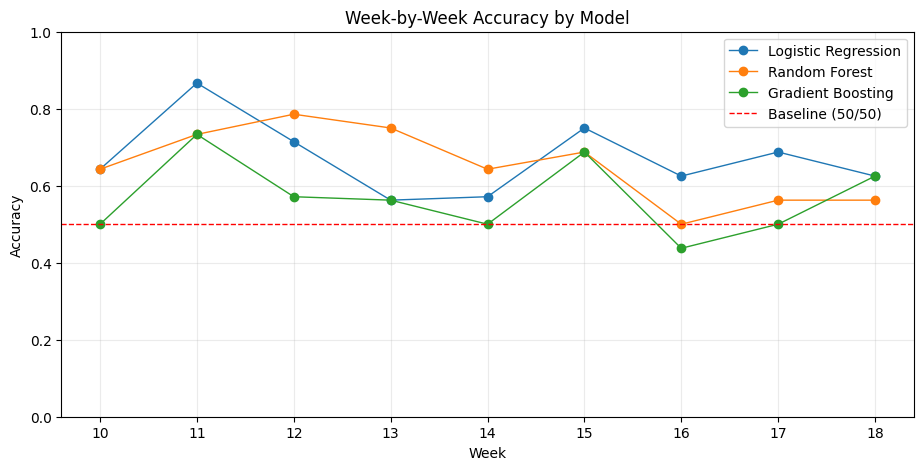

In [108]:
#########################
#
# Week by week visualization of eahc model's accuracy
#
#########################
week_eval_df = test_df.copy()

#create each model's predictions for testing data set weeks(10-18)
week_eval_df["LogisticPred"] = model.predict(x_test)
week_eval_df["RandomForestPred"] = rf_model.predict(x_test)
week_eval_df["GradientBoostingPred"] = gb_model.predict(x_test)

#determine accuracy of each model based on its predictions
weekly_model_accuracy = (
    week_eval_df
    .groupby("Week")
    .apply(
        lambda g: pd.Series({
            "LogisticRegression": (g["LogisticPred"] == g["HomeWin"]).mean(),
            "RandomForest": (g["RandomForestPred"] == g["HomeWin"]).mean(),
            "GradientBoosting": (g["GradientBoostingPred"] == g["HomeWin"]).mean(),
            "Games": len(g)
        })).reset_index()
)

#plot a line graph for each model's accuracy by week
#we also add a 50/50 baseline to show if the model performs better than randomly guessing
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly_model_accuracy["Week"], weekly_model_accuracy["LogisticRegression"], marker="o", linewidth=1, label="Logistic Regression")
ax.plot(weekly_model_accuracy["Week"], weekly_model_accuracy["RandomForest"], marker="o", linewidth=1, label="Random Forest")
ax.plot(weekly_model_accuracy["Week"], weekly_model_accuracy["GradientBoosting"], marker="o", linewidth=1, label="Gradient Boosting")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Baseline (50/50)")
ax.set_title("Week-by-Week Accuracy by Model")
ax.set_xlabel("Week")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()
plt.show()


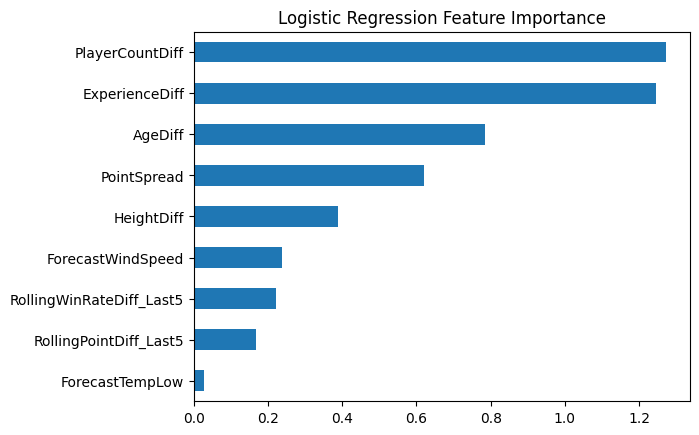

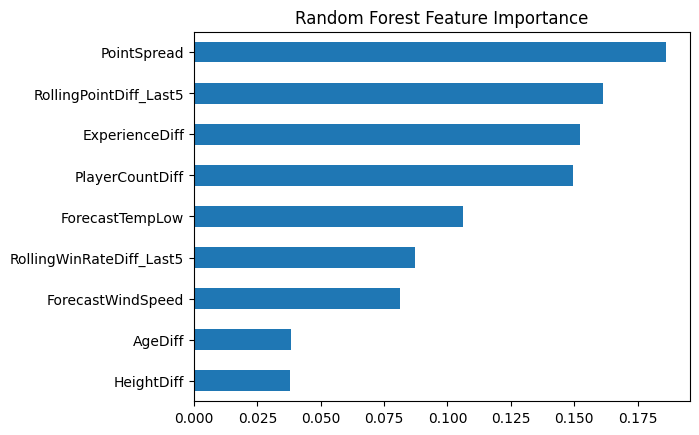

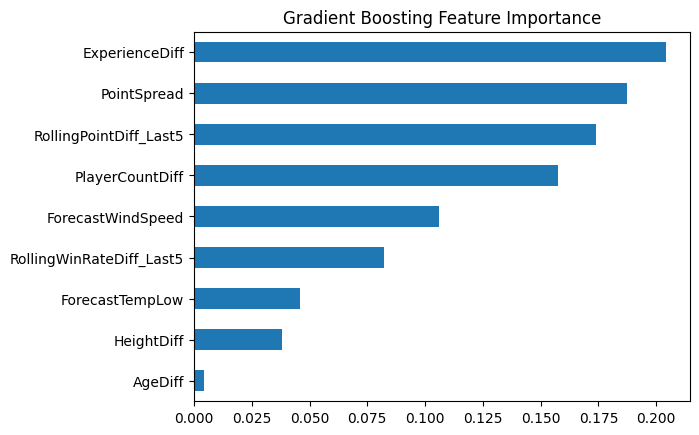

In [109]:
#######################
#
# Feature importance visualization for each model
# This will show, for each model, which features were most important in making predictions
#
#######################

#logistic regression
# logistic regression does not have a built in feature importance method
# so first we have to standardize the coefficients 
# this will show its true feature importance graph
feature_std = x_train[FINAL_FEATURES].std()
lr_feature_importance = pd.Series(
    abs(model.coef_[0]) * feature_std.values,
    index=FINAL_FEATURES
).sort_values(ascending=True)

lr_feature_importance.plot(kind="barh", title="Logistic Regression Feature Importance")
plt.show()

#random forest
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=True)
rf_feature_importance.plot(kind="barh", title="Random Forest Feature Importance")
plt.show()

#gradient boosting
gb_feature_importance = pd.Series(gb_model.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=True)
gb_feature_importance.plot(kind="barh", title="Gradient Boosting Feature Importance")
plt.show()

In [110]:
model_df.to_csv("model_data.csv", index=False)